# Assignment 1: Visualizing German Electricity Generation

## Task Overview
This assignment reconstructs an energy sector visualization from real German electricity generation data (Jan.2024 – Jan.2026). The goal is to demonstrate proficiency in:
- Selecting an appropriate visualization type
- Rebuilding the original plot using Python (Matplotlib/Seaborn)

## Original Visualization
The original chart displays monthly electricity generation by source (renewable and conventional) in Germany over a 2+ year period, with a total consumption line overlay. The stacked area format makes it easy to compare both individual source contributions and the aggregate generation across time.

**Source:**  Agora Energiewende; Stand: 07.05.2026


In [3]:
import pandas as pd
import seaborn as sns


## Load and exploring the data

The dataset contains monthly German electricity generation from January 2024 to January 2026. Each row represents one month, with columns for:
- **Datetime**: Monthly timestamp (first day of month)
- **Renewable sources**: Biomasse, Wasserkraft (hydroelectric), Andere erneuerbare Erzeugung, Wind Offshore, Wind Onshore, Solar
- **Conventional sources**: Konventionell (conventional), plus detailed breakdown
- **Gesamtstromverbrauch**: Total electricity consumption (for comparison)

All values are in TWh (terawatt-hours) per month.

**Data source:**  Agora Energiewende; Stand: 07.05.2026


In [133]:
df = pd.read_csv("overview3.csv")

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Datetime                          25 non-null     object 
 1   Konventionell                     25 non-null     float64
 2   Biomasse                          25 non-null     float64
 3   Wasserkraft                       25 non-null     float64
 4   Andere erneuerbare Erzeugung      25 non-null     float64
 5   Wind Offshore                     25 non-null     float64
 6   Wind Onshore                      25 non-null     float64
 7   Solar                             25 non-null     float64
 8   Braunkohle                        25 non-null     float64
 9   Steinkohle                        25 non-null     float64
 10  Erdgas                            25 non-null     float64
 11  Pumpspeicher                      25 non-null     float64
 12  Andere kon

In [127]:
df.head()

,Datetime,Konventionell,Biomasse,Wasserkraft,Andere erneuerbare Erzeugung,Wind Offshore,Wind Onshore,Solar,Braunkohle,Steinkohle,Erdgas,Pumpspeicher,Andere konventionelle Erzeugung,Gesamtstromverbrauch,Absolute Emissionen,CO₂-Emissionsfaktor des Strommix
0,2024-01-01T00:00:00,21.411849,3.680907,2.112412,0.523338,3.037988,15.264635,1.721438,6.931495,3.478272,8.777085,0.483582,1.741415,46.187891,16.661066,349.232
1,2024-02-01T00:00:00,17.419484,3.447347,1.893887,0.420810,2.782364,13.885761,2.592403,6.184305,2.224817,6.870665,0.467090,1.672608,42.297675,14.042874,329.603
2,2024-03-01T00:00:00,17.973866,3.578141,1.883481,0.340652,2.743038,9.062152,5.481959,6.630046,2.034093,7.049981,0.496259,1.763487,42.859451,14.563839,353.618
3,2024-04-01T00:00:00,14.183080,3.438005,1.852263,0.311552,2.192464,9.373795,7.387836,4.525415,1.380309,6.087333,0.547986,1.642036,41.103270,11.139919,286.583
4,2024-05-01T00:00:00,13.176735,3.475374,2.133224,0.346458,1.523910,6.106442,9.918760,4.999647,0.753138,5.256813,0.548401,1.618737,40.170698,10.749021,291.814


## Preparing the datetime column




In [138]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [129]:
df.head()

,Datetime,Konventionell,Biomasse,Wasserkraft,Andere erneuerbare Erzeugung,Wind Offshore,Wind Onshore,Solar,Braunkohle,Steinkohle,Erdgas,Pumpspeicher,Andere konventionelle Erzeugung,Gesamtstromverbrauch,Absolute Emissionen,CO₂-Emissionsfaktor des Strommix
0,2024-01-01,21.411849,3.680907,2.112412,0.523338,3.037988,15.264635,1.721438,6.931495,3.478272,8.777085,0.483582,1.741415,46.187891,16.661066,349.232
1,2024-02-01,17.419484,3.447347,1.893887,0.420810,2.782364,13.885761,2.592403,6.184305,2.224817,6.870665,0.467090,1.672608,42.297675,14.042874,329.603
2,2024-03-01,17.973866,3.578141,1.883481,0.340652,2.743038,9.062152,5.481959,6.630046,2.034093,7.049981,0.496259,1.763487,42.859451,14.563839,353.618
3,2024-04-01,14.183080,3.438005,1.852263,0.311552,2.192464,9.373795,7.387836,4.525415,1.380309,6.087333,0.547986,1.642036,41.103270,11.139919,286.583
4,2024-05-01,13.176735,3.475374,2.133224,0.346458,1.523910,6.106442,9.918760,4.999647,0.753138,5.256813,0.548401,1.618737,40.170698,10.749021,291.814


In [137]:
print(f"Data range: {df['Datetime'].min()} to {df['Datetime'].max()}")
print(f"Number of months: {len(df)}")

Data range: 2024-01-01T00:00:00 to 2026-01-01T00:00:00
Number of months: 25


## Choosing the columns that belong in the figure

The chart should only show the categories that make sense in the stacked area plot. Keeping the data selection here explicit makes the next plotting step easier to read and easier to modify later.

In [131]:
plot_columns = [
    "Biomasse",
    "Wasserkraft",
    "Andere erneuerbare Erzeugung",
    "Wind Offshore",
    "Wind Onshore",
    "Solar",
    "Konventionell",
]

plot_df = (
    df.set_index("Datetime")
    .sort_index()
    [plot_columns + ["Gesamtstromverbrauch"]]
 )

plot_df.head()

,Biomasse,Wasserkraft,Andere erneuerbare Erzeugung,Wind Offshore,Wind Onshore,Solar,Konventionell,Gesamtstromverbrauch
Datetime,,,,,,,,
2024-01-01,3.680907,2.112412,0.523338,3.037988,15.264635,1.721438,21.411849,46.187891
2024-02-01,3.447347,1.893887,0.420810,2.782364,13.885761,2.592403,17.419484,42.297675
2024-03-01,3.578141,1.883481,0.340652,2.743038,9.062152,5.481959,17.973866,42.859451
2024-04-01,3.438005,1.852263,0.311552,2.192464,9.373795,7.387836,14.183080,41.103270
2024-05-01,3.475374,2.133224,0.346458,1.523910,6.106442,9.918760,13.176735,40.170698


## Build the stacked area chart

`stackplot` is a good fit here because the plot shows how several sources add up to a total over time. The pink line helps compare the stacked sources against the overall electricity consumption.

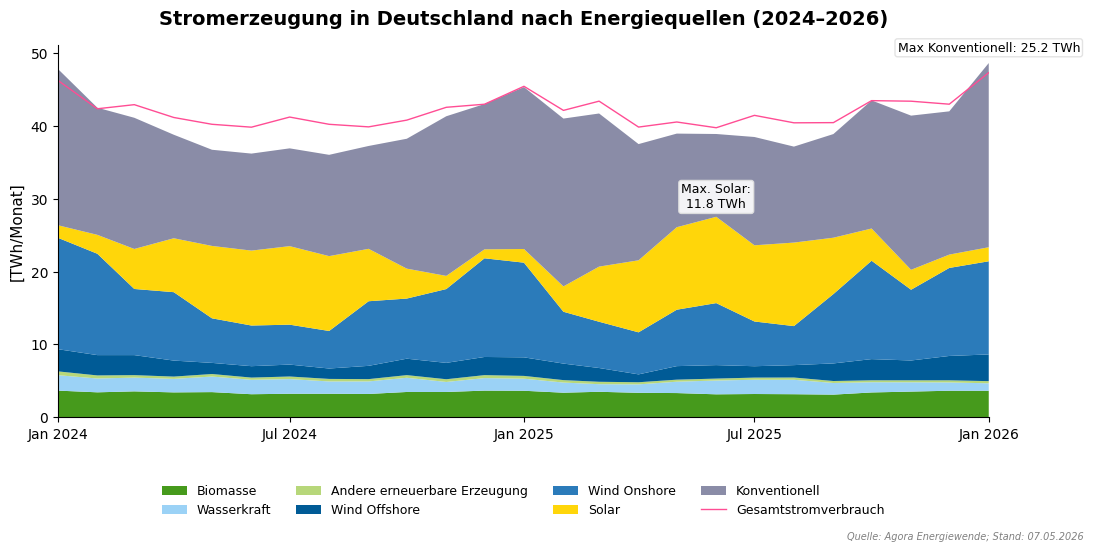

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

colors = ["#469a1c","#9bd2f6", "#b7d77a", "#005b96", "#2b7bba", "#ffd60a", "#8a8ca7",]

fig, ax = plt.subplots(figsize=(11, 5.5))




ax.stackplot(
    plot_df.index,
    plot_df[plot_columns].T,
    labels=plot_columns,
    colors=colors,
    alpha=1.0,)

ax.plot(
    plot_df.index,
    plot_df["Gesamtstromverbrauch"],
    color="#ff4d94",
    linewidth=1,
    label="Gesamtstromverbrauch",)

# Adding title and labels
ax.set_title(
    "Stromerzeugung in Deutschland nach Energiequellen (2024–2026)",
    fontsize=14,
    fontweight="bold",
    pad=15,)
ax.set_ylabel("[TWh/Monat]", fontsize=11)
ax.set_xlabel("", fontsize=11)

# Seting axis limits and formatting
ax.set_xlim(plot_df.index.min(), plot_df.index.max())

# Seting  x axis ticks every 6 months 
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=0)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize=9,)

# Removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0)

fig.text(
    0.99,
    0.01,
    "Quelle: Agora Energiewende; Stand: 07.05.2026",
    fontsize=7,
    ha="right",
    style="italic",
    color="gray",)


max_solar_date = plot_df["Solar"].idxmax()
solar_val = plot_df["Solar"].max()
ax.annotate(
    f"Max. Solar:\n{solar_val:.1f} TWh",
    xy=(max_solar_date, solar_peak_height + 0.8),
    fontsize=9,
    ha="center",  
    va="bottom",  
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e0e0e0", lw=1, alpha=0.9)
)


max_konv_date = plot_df["Konventionell"].idxmax()
konv_val = plot_df["Konventionell"].max()
total_height = plot_df.loc[max_konv_date, plot_columns].sum()
ax.annotate(
    f"Max Konventionell: {konv_val:.1f} TWh",
    xy=(max_konv_date, total_height + 1.2), 
    fontsize=9,
    ha="center",   
    va="bottom", 
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e0e0e0", lw=1, alpha=0.9)
)
plt.tight_layout()
plt.show()